In [ ]:
import scanpy as sc
from pathlib import Path
import sys
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

repo_root = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

adata = sc.read_h5ad("/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/MOSTA/mosta_affine.h5ad")

adata_subset = adata[adata.obs['time'] <= 13.5]

print(adata.obs['time'].unique())

for time in adata.obs['time'].unique():
    print(adata[adata.obs['time'] == time].n_obs)

[ 9.5 10.5 11.5 12.5 13.5 14.5 15.5 16.5]
5870
17776
29972
51201
76717
102466
112685
121480


In [10]:
import numpy as np
adata_for_fgw = adata_subset
time_series = adata_for_fgw.obs["time"]
time_values = sorted(np.unique(time_series.to_numpy()).tolist())

selected_pairs = []
for i in range(len(time_values)):
    for j in range(i + 1, len(time_values)):
        selected_pairs.append((time_values[i], time_values[j]))
        if j - i == 2:
            break

In [6]:
# Cell 36: 准备参数与公共组件 + 计算并保存 FGWOT pi（不使用 wandb）
working_dir =  "/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ot_pis"
data_name = "mosta"
fgw_alpha = 0.5
seed = 42

# New option: whether to normalize OT plan mass to 1.
# True keeps previous behavior.
ot_plan_normalize = False

from pathlib import Path
import numpy as np
from moscot.problems.spatiotemporal import SpatioTemporalProblem

In [ ]:
# 5) FGWOT pi 缓存路径（本单元只写入，不读取）
pi_cache_dir = Path(working_dir)
pi_cache_dir.mkdir(parents=True, exist_ok=True)
pi_cache_path = pi_cache_dir / f"fgwot_pi_{data_name}_alpha{fgw_alpha}_10_12_gene_triu.npz"

# 6) 计算每个相邻时间段 FGWOT 的 pi 并保存
print("Computing FGWOT pi and writing cache...")
adata_for_fgw = adata_subset
spatial_key = "spatial"
# adata_for_fgw.obsm['X_ae'] = adata_for_fgw.obsm['X_ae'] / adata_for_fgw.obsm['X_ae'].max()

time_series = adata_for_fgw.obs["time"]
time_values = sorted(np.unique(time_series.to_numpy()).tolist())

selected_pairs = [()]
# for i in range(len(time_values)):
#     for j in range(i + 1, len(time_values)):
#         selected_pairs.append((time_values[i], time_values[j]))
#         if j - i == 2:
#             break

problem = SpatioTemporalProblem(adata_for_fgw)

problem = problem.prepare(
    time_key="time",
    spatial_key=spatial_key,
    policy="explicit",
    subset=selected_pairs,
    joint_attr={"attr": "X"},   # 关键：直接用 adata.X，不做默认 PCA
    cost={
        "xy": "sq_euclidean",   # gene expression term
        "x": "sq_euclidean",    # source spatial structure
        "y": "sq_euclidean",    # target spatial structure
    },
)
problem = problem.solve(alpha=float(fgw_alpha), epsilon=0, rank=200, tau_a = 0.97, tau_b = 0.93)

pi_by_transition = {}
cache_payload = {}
for pair in selected_pairs:
    timea = pair[0]
    timeb = pair[1]
    pi = np.asarray(problem.solutions[(timea, timeb)].transport_matrix, dtype=np.float64)
    pi = np.clip(pi, a_min=0.0, a_max=None)
    mass = float(pi.sum())
    if mass <= 0:
        raise ValueError(f"Invalid pi mass for transition {timea}->{timeb}")
    if ot_plan_normalize:
        pi = pi / mass
    pi_by_transition[(timea, timeb)] = pi
    cache_payload[f"transition_{timea}_{timeb}"] = pi
    print(f"transition {timea}->{timeb}, pi shape={pi.shape}, total mass={float(pi.sum()):.6f}")

np.savez_compressed(pi_cache_path, **cache_payload)
print(f"Saved FGWOT pi cache to: {pi_cache_path}")

# del adata_for_fgw

# 7) 统一 run_id（用于 checkpoint 路径，不依赖 wandb）
run_id = f"notebook_seed{seed}"

print("seed:", seed)
print("run_id:", run_id)
print("data_name:", data_name)
print("fgw_alpha:", fgw_alpha)
print("ot_plan_normalize:", ot_plan_normalize)
print("precomputed transitions:", sorted(pi_by_transition.keys()))
print("pi_cache_path:", pi_cache_path)
print("WandB disabled in this notebook pipeline.")

Computing FGWOT pi and writing cache...


/data/yuz/envs/nicheflow/lib/python3.11/site-packages/moscot/problems/time/_mixins.py:910: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  self.adata.obs[key] = self.adata.obs[key].astype("category")


INFO     Normalizing spatial coordinates of `x`.                                                                   
INFO     Normalizing spatial coordinates of `y`.                                                                   
INFO     Normalizing spatial coordinates of `x`.                                                                   
INFO     Normalizing spatial coordinates of `y`.                                                                   
INFO     Normalizing spatial coordinates of `x`.                                                                   
INFO     Normalizing spatial coordinates of `y`.                                                                   
INFO     Normalizing spatial coordinates of `x`.                                                                   
INFO     Normalizing spatial coordinates of `y`.                                                                   
INFO     Normalizing spatial coordinates of `x`.                        

In [14]:
# Cell 37: 读取 FGWOT pi 缓存并构建 ot_sampler
import importlib
import core.utils.fgwot as fgwot_mod
import numpy as np

ot_plan_normalize = False
dataset_name = "mosta" #mosta_subset_unaffine
fgw_alpha = 0.5

fgwot_mod = importlib.reload(fgwot_mod)
FGWOTPlanSampler = fgwot_mod.FGWOTPlanSampler

# New option: whether to normalize OT plan after loading.
# If cell 36 already set this value, reuse it.
ot_plan_normalize = bool(globals().get('ot_plan_normalize', True))
working_dir =  "/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ot_pis"
pi_cache_dir = Path(working_dir)
pi_cache_dir.mkdir(parents=True, exist_ok=True)
pi_cache_path = pi_cache_dir / f"fgwot_pi_{dataset_name}_alpha{fgw_alpha}_9_13_gene_triu.npz"
pi_by_transition = {}
if pi_cache_path.exists():
    print(f"Loading precomputed FGWOT pi from: {pi_cache_path}")
    cached = np.load(pi_cache_path, allow_pickle=False)
    transition_keys = []
    for key in cached.files:
        if key.startswith("transition_"):
            timea = float(key.split("_")[1])
            timeb = float(key.split("_")[2])
            transition_keys.append((timea, timeb))
            pi = np.asarray(cached[key], dtype=np.float64)
            pi = np.clip(pi, a_min=0.0, a_max=None)
            mass = float(pi.sum())
            if mass <= 0:
                raise ValueError(f"Invalid cached pi mass for transition {timea}->{timeb}")
            if ot_plan_normalize:
                pi = pi / mass
            pi_by_transition[(timea, timeb)] = pi
    if not transition_keys:
        raise ValueError(f"No transition_* arrays found in cache: {pi_cache_path}")
    print("Loaded transitions:", sorted(transition_keys))
else:
    raise FileNotFoundError(f"FGWOT cache not found: {pi_cache_path}")

ot_sampler = FGWOTPlanSampler(pi_matrix=pi_by_transition, normalize_pi=ot_plan_normalize)
print("ot_sampler:", type(ot_sampler).__name__)
print("transitions:", sorted(pi_by_transition.keys()))
print("ot_plan_normalize:", ot_plan_normalize)

Loading precomputed FGWOT pi from: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ot_pis/fgwot_pi_mosta_alpha0.5_9_13_gene_triu.npz
Loaded transitions: [(9.5, 10.5), (9.5, 11.5), (10.5, 11.5), (10.5, 12.5), (11.5, 12.5), (11.5, 13.5), (12.5, 13.5)]
ot_sampler: FGWOTPlanSampler
transitions: [(9.5, 10.5), (9.5, 11.5), (10.5, 11.5), (10.5, 12.5), (11.5, 12.5), (11.5, 13.5), (12.5, 13.5)]
ot_plan_normalize: False


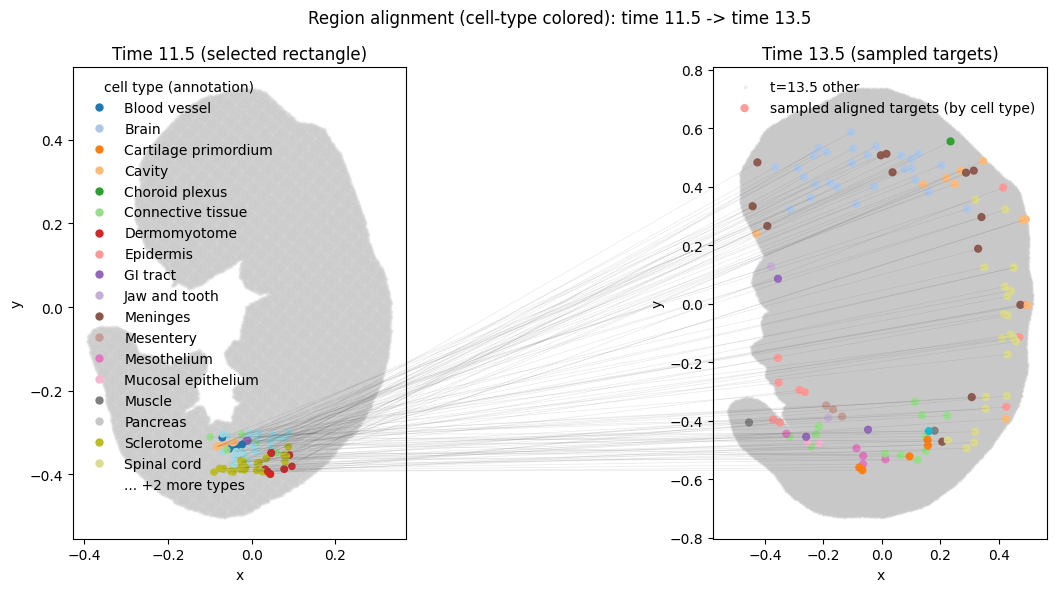

selected rectangle: x in [-0.1, 0.1], y in [-0.4, -0.3]
matched transition key: (11.5, 13.5), transposed: False
sampling mode: sample_map-style global flatten on region block, seed=2026, replace=True
cell type key: annotation
drawn source cells (with replacement): 120
unique sampled source cells in t=11.5: 73
unique sampled cells in t=13.5: 119
cell types in aligned pairs: 20


In [33]:
# 指定局部区域对齐可视化（按细胞类型着色）
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from matplotlib.lines import Line2D

# adata = adata_subset

source_timepoint = 11.5
target_timepoint = 13.5

# 1) 取两个时间点数据
t_obs_key = "time"
times = np.asarray(adata.obs[t_obs_key]).astype(float)
maska = np.isclose(times, source_timepoint)
maskb = np.isclose(times, target_timepoint)

Sa_all = np.asarray(adata.obsm["spatial"][maska], dtype=np.float64)
Sb_all = np.asarray(adata.obsm["spatial"][maskb], dtype=np.float64)

na, nb = Sa_all.shape[0], Sb_all.shape[0]
if na == 0 or nb == 0:
    raise ValueError("No cells found at time=2.0 or time=10.0")

obs_type_key = "annotation"

def _get_types(mask, n):
    if obs_type_key is None:
        return np.array(["unknown"] * n, dtype=object)
    vals = np.asarray(adata.obs.loc[mask, obs_type_key]).astype(str)
    vals[vals == "nan"] = "unknown"
    return vals

types10_all = _get_types(maska, na)
types15_all = _get_types(maskb, nb)

# 2) 选取指定矩形区域
x_min, x_max = -0.1, 0.1
y_min, y_max = -0.4, -0.3

region_mask = (
    (Sa_all[:, 0] >= x_min)
    & (Sa_all[:, 0] <= x_max)
    & (Sa_all[:, 1] >= y_min)
    & (Sa_all[:, 1] <= y_max)
)
region_idx = np.where(region_mask)[0]
# region_idx = np.where(adata[adata.obs['time'] == 10.0].obs['Annotation'].isin(["reaEGC", "rIPC1", "IMN", "nptxEX"]))[0]
# region_idx = np.where(adata[adata.obs['time'] == source_timepoint].obs['annotation'].isin(["Spinal cord"]))[0]

# 可选: 限制连线数，避免图过密
max_lines = 120
if region_idx.size > max_lines:
    rng_sub = np.random.default_rng(42)
    region_idx = np.sort(rng_sub.choice(region_idx, size=max_lines, replace=False))

# 3) 自动匹配对应时间段的对齐矩阵
matched_key = None
P = None
transposed = False

for k in sorted(pi_by_transition.keys()):
    pi = np.asarray(pi_by_transition[k], dtype=np.float64)
    if pi.ndim != 2:
        continue
    if pi.shape == (na, nb) or pi.shape == (nb, na):
        matched_key = k
        P = pi
        transposed = False if pi.shape == (na, nb) else True
        break

# 4) sample_map 风格采样（在区域子矩阵上 flatten 采样）
P_nonneg = np.clip(P, a_min=0.0, a_max=None)
P_region = P_nonneg[region_idx, :]  # shape: (n_region, nb)

total_mass = float(P_region.sum())
if total_mass <= 1e-16:
    raise ValueError("Selected region has zero transport mass; cannot sample.")

p_flat = (P_region / total_mass).reshape(-1)
sample_seed = 2026
rng = np.random.default_rng(sample_seed)

choices = rng.choice(
    P_region.shape[0] * P_region.shape[1],
    size=region_idx.size,
    replace=True,
    p=p_flat,
)
row_local, aligned_idx = np.divmod(choices, P_region.shape[1])

source_idx = region_idx[row_local]
Sa_region = Sa_all[source_idx]
Sb_aligned = Sb_all[aligned_idx]

# 当前对齐对的细胞类型（左右各自按对应时间点类型着色）
type_src = types10_all[source_idx]
type_tgt = types15_all[aligned_idx]
types_union = np.unique(np.concatenate([type_src, type_tgt]))
n_types = int(types_union.size)

if n_types <= 20:
    cmap = plt.get_cmap("tab20", max(n_types, 1))
else:
    cmap = plt.get_cmap("gist_ncar", n_types)
type_to_color = {t: cmap(i) for i, t in enumerate(types_union)}

colors_src = [type_to_color[t] for t in type_src]
colors_tgt = [type_to_color[t] for t in type_tgt]

# 5) 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax_l, ax_r = axes

x_min, x_max = -0.1, 0.1
y_min, y_max = -0.4, -0.3

ax_l.scatter(Sa_all[:, 0], Sa_all[:, 1], s=4, c="#c8c8c8", alpha=0.25, label=f"t={source_timepoint} other")
ax_l.scatter(Sa_region[:, 0], Sa_region[:, 1], s=20, c=colors_src, alpha=0.95, label=f"selected region (by cell type)")
# ax_l.plot([x_min, x_max, x_max, x_min, x_min], [y_min, y_min, y_max, y_max, y_min], color="#d62728", lw=1.5)
ax_l.set_title(f"Time {source_timepoint} (selected rectangle)")
ax_l.set_xlabel("x")
ax_l.set_ylabel("y")
ax_l.set_aspect("equal", adjustable="box")

ax_r.scatter(Sb_all[:, 0], Sb_all[:, 1], s=4, c="#c8c8c8", alpha=0.25, label=f"t={target_timepoint} other")
ax_r.scatter(Sb_aligned[:, 0], Sb_aligned[:, 1], s=24, c=colors_tgt, alpha=0.95, label="sampled aligned targets (by cell type)")
ax_r.set_title(f"Time {target_timepoint} (sampled targets)")
ax_r.set_xlabel("x")
ax_r.set_ylabel("y")
ax_r.set_aspect("equal", adjustable="box")

n_lines = Sa_region.shape[0]
for i in range(n_lines):
    con = ConnectionPatch(
        xyA=(Sa_region[i, 0], Sa_region[i, 1]),
        coordsA=ax_l.transData,
        xyB=(Sb_aligned[i, 0], Sb_aligned[i, 1]),
        coordsB=ax_r.transData,
        color="#4f4f4f",
        alpha=0.12,
        lw=0.5,
    )
    fig.add_artist(con)

# 图例过多时只展示前若干类，避免遮挡
legend_limit = 18
types_for_legend = sorted(types_union.tolist())
if len(types_for_legend) > legend_limit:
    shown_types = types_for_legend[:legend_limit]
    hidden_n = len(types_for_legend) - legend_limit
else:
    shown_types = types_for_legend
    hidden_n = 0

handles = [
    Line2D([0], [0], marker="o", linestyle="", markersize=6, markerfacecolor=type_to_color[t], markeredgecolor="none", label=t)
    for t in shown_types
]
if hidden_n > 0:
    handles.append(Line2D([0], [0], linestyle="", label=f"... +{hidden_n} more types"))

ax_l.legend(handles=handles, loc="best", frameon=False, title=f"cell type ({obs_type_key if obs_type_key else 'fallback'})")
ax_r.legend(loc="best", frameon=False)
plt.suptitle(f"Region alignment (cell-type colored): time {source_timepoint} -> time {target_timepoint}")
plt.tight_layout()
plt.show()

print(f"selected rectangle: x in [{x_min}, {x_max}], y in [{y_min}, {y_max}]")
print(f"matched transition key: {matched_key}, transposed: {transposed}")
print(f"sampling mode: sample_map-style global flatten on region block, seed={sample_seed}, replace=True")
print(f"cell type key: {obs_type_key if obs_type_key is not None else 'None (fallback=unknown)'}")
print(f"drawn source cells (with replacement): {Sa_region.shape[0]}")
print(f"unique sampled source cells in t={source_timepoint}: {np.unique(source_idx).size}")
print(f"unique sampled cells in t={target_timepoint}: {np.unique(aligned_idx).size}")
print(f"cell types in aligned pairs: {n_types}")

In [16]:
adata[adata.obs['time'] == 11.5]

View of AnnData object with n_obs × n_vars = 29972 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'annotation', 'Regulon - Arx', 'Regulon - Bclaf1', 'Regulon - Bmyc', 'Regulon - Brf1', 'Regulon - Cdx2', 'Regulon - Creb1', 'Regulon - Ctcf', 'Regulon - Cux1', 'Regulon - Dbx1', 'Regulon - Dlx5', 'Regulon - Dlx6', 'Regulon - E2f1', 'Regulon - E2f2', 'Regulon - E2f3', 'Regulon - E2f4', 'Regulon - E2f5', 'Regulon - E2f6', 'Regulon - E2f7', 'Regulon - E2f8', 'Regulon - Elf1', 'Regulon - Elf2', 'Regulon - Elk3', 'Regulon - Emx2', 'Regulon - Esrra', 'Regulon - Ets1', 'Regulon - Ets2', 'Regulon - Etv6', 'Regulon - Evx1', 'Regulon - Ezh2', 'Regulon - Fli1', 'Regulon - Foxa1', 'Regulon - Foxa2', 'Regulon - Foxa3', 'Regulon - Foxc2', 'Regulon - Foxf1', 'Regulon - Foxo1', 'Regulon - Foxp2', 'Regulon - Gabpa', 'Regulon - Gata1', 'Regulon - Gata4', 'Regulon - Gata5', 'Regulon - Gata6', 'Regulon - Gbx2', 'Regulon - Gsx1', 'Regulon - Gtf2f1', 'Regul

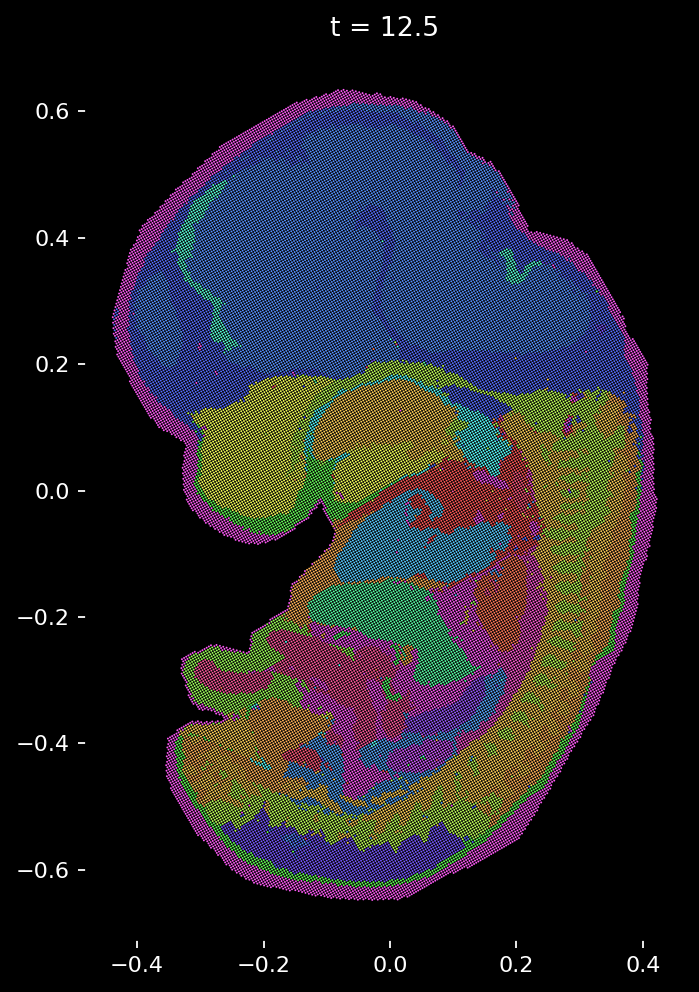

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ===== 参数 =====
timepoint = 12.5
time_key = "time"
spatial_key = "spatial"   # 或 "spatial"
anno_key = "annotation"

color_by_annotation = True
single_color = "#00E5FF"

point_size = 3.0
figsize = (6, 6)
background = "black"

# ===== 取切片 =====
mask = np.isclose(np.asarray(adata.obs[time_key]).astype(float), timepoint)

coords = np.asarray(adata.obsm[spatial_key][mask], dtype=float)
if coords.shape[1] > 2:
    coords = coords[:, :2]

if coords.shape[0] == 0:
    raise ValueError(f"No cells found at time={timepoint}")

# ===== 画图 =====
fig, ax = plt.subplots(figsize=figsize, dpi=160)
fig.patch.set_facecolor(background)
ax.set_facecolor(background)

if color_by_annotation:
    ann = adata.obs.loc[mask, anno_key].astype(str).to_numpy()
    ann_levels = np.unique(ann)
    ann_to_idx = {a: i for i, a in enumerate(ann_levels)}
    color_idx = np.asarray([ann_to_idx[a] for a in ann], dtype=int)

    n_ann = len(ann_levels)
    hues = (np.arange(n_ann) * 0.618033988749895) % 1.0
    rgb = plt.cm.hsv(hues)[:, :3]
    ann_colors = 0.35 + 0.65 * rgb
    cmap = ListedColormap(ann_colors)

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=color_idx,
        cmap=cmap,
        s=point_size,
        marker=".",
        linewidths=0,
        alpha=1.0,
    )
else:
    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=single_color,
        s=point_size,
        marker=".",
        linewidths=0,
        alpha=1.0,
    )

ax.set_title(f"t = {timepoint}", color="white")
ax.set_aspect("equal", adjustable="box")
ax.set_axis_on()
ax.tick_params(colors="white")

plt.tight_layout(pad=0)
plt.show()

In [32]:
adata.obs['Batch'].unique()


['E9.5_E1S1', 'E10.5_E1S1', 'E11.5_E1S1', 'E12.5_E1S1', 'E13.5_E1S1', 'E14.5_E1S1', 'E15.5_E1S1', 'E16.5_E1S1']
Categories (8, object): ['E9.5_E1S1', 'E10.5_E1S1', 'E11.5_E1S1', 'E12.5_E1S1', 'E13.5_E1S1', 'E14.5_E1S1', 'E15.5_E1S1', 'E16.5_E1S1']

In [29]:
adata[adata.obs['time'] == 12.5].obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,annotation,Regulon - Arx,Regulon - Bclaf1,Regulon - Bmyc,Regulon - Brf1,Regulon - Cdx2,...,Module_18,Module_19,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,Batch,n_genes,time,time_input
cell_name,,,,,,,,,,,,,,,,,,,,,
100_124,211,5.356586,391,5.971262,Cavity,0.000021,0.037876,0.018724,0.089679,0.003817,...,-0.732878,-0.682813,51.406650,71.611253,97.186701,100.000000,E12.5_E1S1,211,12.5,3.0
100_125,680,6.523562,1497,7.311886,Cavity,0.000000,0.050318,0.027932,0.007685,0.000832,...,-0.761371,-0.698921,34.134937,46.492986,63.259853,87.975952,E12.5_E1S1,680,12.5,3.0
100_126,917,6.822197,2182,7.688455,Brain,0.000000,0.044709,0.073360,0.043778,0.000367,...,-0.752497,-0.702647,31.393217,42.483960,58.020165,80.889093,E12.5_E1S1,917,12.5,3.0
100_127,1025,6.933423,2389,7.779049,Brain,0.000000,0.053128,0.037082,0.020387,0.000254,...,-0.733308,-0.725947,30.640435,40.895772,55.253244,78.024278,E12.5_E1S1,1025,12.5,3.0
100_128,1200,7.090910,3026,8.015327,Brain,0.000000,0.050421,0.053762,0.055528,0.002463,...,-0.734119,-0.583934,29.246530,38.929280,52.115003,75.578321,E12.5_E1S1,1200,12.5,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99_272,1323,7.188413,3494,8.159089,Cavity,0.035802,0.059985,0.063102,0.099100,0.038473,...,-0.525701,-0.651494,30.709788,39.610761,51.774471,73.125358,E12.5_E1S1,1323,12.5,3.0
99_273,1259,7.138867,3270,8.092851,Cavity,0.024446,0.060788,0.037474,0.019908,0.000473,...,-0.495279,-0.679804,31.467890,40.397554,52.599388,74.984709,E12.5_E1S1,1259,12.5,3.0
99_274,1363,7.218177,3888,8.265907,Cavity,0.000000,0.062449,0.093630,0.065421,0.013223,...,-0.540131,-0.697189,32.201646,40.792181,52.186214,73.405350,E12.5_E1S1,1363,12.5,3.0
